<div align="center">

# 03 · Drift Detection

### Production Quality Drift Detector

</div>



In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

def find_data_file(filename):
    paths = [
        Path.cwd() / "Data" / filename,
        Path.cwd().parent / "Data" / filename
    ]
    for path in paths:
        if path.is_file():
            return path
    raise FileNotFoundError(f"{filename} was not found in the project Data folder.")

DATA_PATH = find_data_file("Data_features.csv")
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


Loaded: d:\Sarthak's Folder\Project\Hackathon\Data\Data_features.csv
Shape: 14,992 rows × 82 columns


In [2]:
def normalize_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[%/()\-]+", "_", name)
    name = re.sub(r"[^a-z0-9_]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")

ALIASES = {
    "batch_id": ["batch_id", "batch", "batch_number", "batch_no", "lot_id", "lot_number"],
    "timestamp": ["timestamp", "datetime", "date_time", "date", "recorded_at", "recorded_time"],
    "machine_id": ["machine_id", "machine", "machine_no", "machine_number", "equipment_id"],
    "product_line": ["product_line", "production_line", "line", "line_id", "product"],
    "temperature": ["temperature", "temp", "temp_c", "temperature_c", "temperature_celsius"],
    "pressure": ["pressure", "press", "pressure_psi", "pressure_bar"],
    "cycle_time": ["cycle_time", "cycle_duration", "cycle_time_sec", "duration", "processing_time"],
    "vibration": ["vibration", "vibration_level", "vibration_mm_s", "vibration_rms"],
    "quality_measurement": ["quality_measurement", "quality_score", "quality", "quality_index"],
    "defect_rate": ["defect_rate", "defect_percentage", "defect_pct", "defect_ratio"],
    "actual_status": ["actual_status", "status", "process_status", "quality_status", "condition"],
    "final_outcome": ["final_outcome", "outcome", "result", "final_result", "decision"],
    "temperature_tolerance": ["temperature_tolerance", "temp_tolerance", "temperature_limit", "temp_limit"],
    "pressure_tolerance": ["pressure_tolerance", "pressure_limit", "pressure_upper_limit"],
    "cycle_time_tolerance": ["cycle_time_tolerance", "cycle_tolerance", "cycle_time_limit"],
    "vibration_tolerance": ["vibration_tolerance", "vibration_limit", "vibration_upper_limit"]
}

def detect_column(concept):
    normalized = {normalize_name(c): c for c in df.columns}
    for alias in ALIASES.get(concept, []):
        key = normalize_name(alias)
        if key in normalized:
            return normalized[key]
    return None

COLUMN_MAP = {concept: detect_column(concept) for concept in ALIASES}
display(pd.DataFrame([{"concept": k, "column": v or "NOT FOUND"} for k, v in COLUMN_MAP.items()]))


,concept,column
0,batch_id,batch_id
1,timestamp,timestamp
2,machine_id,machine_id
3,product_line,product_line
4,temperature,temperature
5,pressure,pressure
6,cycle_time,cycle_time
7,vibration,vibration
8,quality_measurement,quality_measurement
9,defect_rate,defect_rate


# 01 · Detection Configuration

In [3]:
Z_THRESHOLD = 3.0
WARNING_SCORE = 0.30
CRITICAL_SCORE = 0.60
NEAR_LIMIT_PCT = 90.0

PROCESS_CONCEPTS = ["temperature", "pressure", "cycle_time", "vibration"]

available_process = {
    concept: COLUMN_MAP[concept]
    for concept in PROCESS_CONCEPTS
    if COLUMN_MAP.get(concept)
}

print("Detected process variables:")
for concept, col in available_process.items():
    print(f"{concept}: {col}")


Detected process variables:
temperature: temperature
pressure: pressure
cycle_time: cycle_time
vibration: vibration


# 02 · Statistical Signals

In [4]:
for concept, col in available_process.items():
    z_col = f"{concept}_rolling_z"

    if z_col not in df.columns:
        value = pd.to_numeric(df[col], errors="coerce")
        mean = value.rolling(25, min_periods=12).mean()
        std = value.rolling(25, min_periods=12).std()
        df[z_col] = (value - mean) / std.replace(0, np.nan)

    df[f"{concept}_z_signal"] = (df[z_col].abs() >= Z_THRESHOLD).astype(int)

print("Statistical signals created.")


Statistical signals created.


# 03 · Tolerance Signals

In [5]:
for concept in available_process:
    utilization_col = f"{concept}_tolerance_utilization_pct"
    distance_col = f"{concept}_tolerance_distance"

    if utilization_col in df.columns:
        df[f"{concept}_tolerance_signal"] = (
            df[utilization_col] >= NEAR_LIMIT_PCT
        ).astype(int)
    elif distance_col in df.columns:
        df[f"{concept}_tolerance_signal"] = (
            df[distance_col] <= 0
        ).astype(int)

print("Tolerance signals created.")


Tolerance signals created.


# 04 · Directional Drift

In [6]:
for concept in available_process:
    mean_col = f"{concept}_rolling_mean"
    std_col = f"{concept}_rolling_std"

    if mean_col not in df.columns or std_col not in df.columns:
        continue

    previous = df[mean_col].shift(25)
    df[f"{concept}_mean_shift"] = df[mean_col] - previous

    df[f"{concept}_directional_signal"] = (
        df[f"{concept}_mean_shift"].abs() >
        df[std_col].replace(0, np.nan)
    ).astype(int)

print("Directional signals created.")


Directional signals created.


# 05 · Quality and Defect Support

In [7]:
df["defect_signal"] = (
    df["defect_rate_pct_change"] > 10
).astype(int) if "defect_rate_pct_change" in df.columns else 0

df["quality_signal"] = (
    df["quality_pct_change"] < -10
).astype(int) if "quality_pct_change" in df.columns else 0

print("Quality and defect support signals created.")


Quality and defect support signals created.


# 06 · Variable Drift Scores

In [8]:
variable_scores = []

for concept in available_process:
    cols = [
        f"{concept}_z_signal",
        f"{concept}_tolerance_signal",
        f"{concept}_directional_signal"
    ]
    cols = [c for c in cols if c in df.columns]

    if cols:
        score_col = f"{concept}_drift_score"
        df[score_col] = df[cols].mean(axis=1)
        variable_scores.append(score_col)

print("Variable score columns:")
print(variable_scores)


Variable score columns:
['temperature_drift_score', 'pressure_drift_score', 'cycle_time_drift_score', 'vibration_drift_score']


# 07 · Overall Drift Score

In [9]:
if variable_scores:
    df["process_drift_score"] = df[variable_scores].mean(axis=1)
else:
    df["process_drift_score"] = 0.0

supporting = df[["defect_signal", "quality_signal"]].mean(axis=1)

df["drift_score"] = (
    0.80 * df["process_drift_score"] +
    0.20 * supporting
).clip(0, 1)

display(df["drift_score"].describe().to_frame("drift_score").round(4))


,drift_score
count,"14,992.0000"
mean,0.1718
std,0.0851
min,0.0000
25%,0.1333
50%,0.1667
75%,0.2333
max,0.6000


# 08 · Stable / Warning / Critical

In [10]:
df["detected_status"] = np.select(
    [
        df["drift_score"] >= CRITICAL_SCORE,
        df["drift_score"] >= WARNING_SCORE
    ],
    [
        "Critical",
        "Warning"
    ],
    default="Stable"
)

status_summary = (
    df["detected_status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="batch_count")
)

status_summary["percentage"] = status_summary["batch_count"] / len(df) * 100
display(status_summary.round(2))


,status,batch_count,percentage
0,Stable,13438,89.6300
1,Warning,1553,10.3600
2,Critical,1,0.0100


# 09 · Variable Responsibility

In [11]:
if variable_scores:
    variable_report = pd.DataFrame({
        "variable": [c.replace("_drift_score", "") for c in variable_scores],
        "mean_drift_score": [df[c].mean() for c in variable_scores],
        "max_drift_score": [df[c].max() for c in variable_scores],
        "high_score_observations": [int((df[c] >= 0.60).sum()) for c in variable_scores]
    }).sort_values("mean_drift_score", ascending=False)

    display(variable_report.round(4))
else:
    variable_report = pd.DataFrame()
    print("No variable-level scores available.")


,variable,mean_drift_score,max_drift_score,high_score_observations
1,pressure,0.3202,0.6667,53
0,temperature,0.2214,0.6667,32
3,vibration,0.0514,0.6667,31
2,cycle_time,0.0487,0.6667,15


# 10 · Drift Timeline

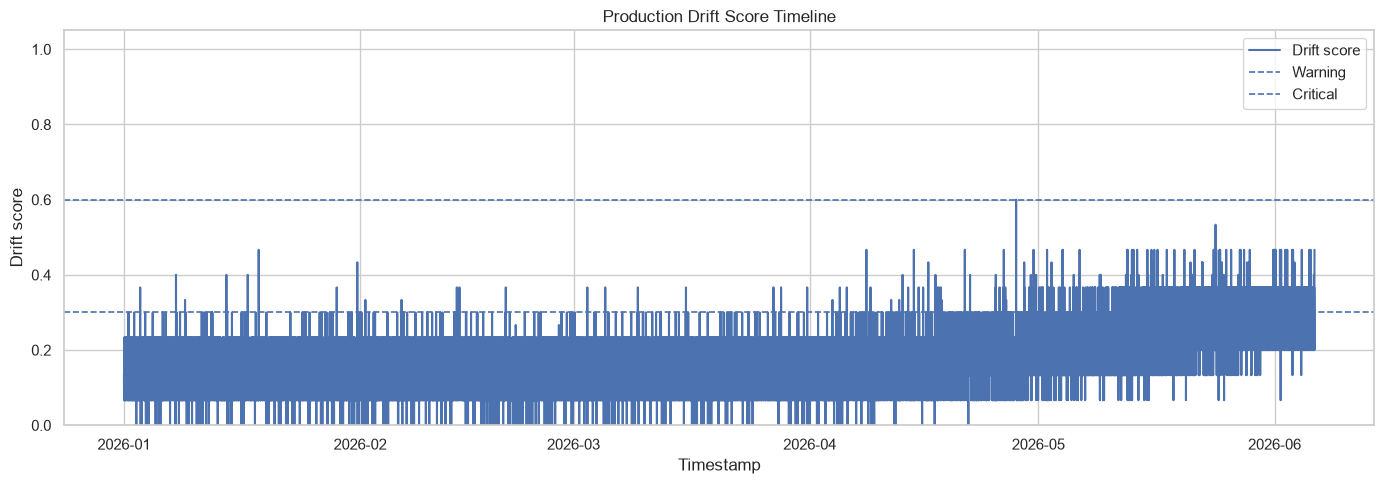

In [12]:
timestamp_col = COLUMN_MAP.get("timestamp")
x = (
    pd.to_datetime(df[timestamp_col], errors="coerce")
    if timestamp_col and timestamp_col in df.columns
    else np.arange(len(df))
)

plt.figure(figsize=(14, 5))
plt.plot(x, df["drift_score"], linewidth=1.5, label="Drift score")
plt.axhline(WARNING_SCORE, linestyle="--", linewidth=1.2, label="Warning")
plt.axhline(CRITICAL_SCORE, linestyle="--", linewidth=1.2, label="Critical")
plt.title("Production Drift Score Timeline")
plt.xlabel("Timestamp" if timestamp_col else "Production sequence")
plt.ylabel("Drift score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


# 11 · Optional Isolation Forest

In [13]:
try:
    from sklearn.ensemble import IsolationForest

    model_cols = [
        col for col in available_process.values()
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
    ]

    if model_cols:
        model_data = df[model_cols].replace([np.inf, -np.inf], np.nan)
        model_data = model_data.fillna(model_data.median())

        model = IsolationForest(
            n_estimators=200,
            contamination="auto",
            random_state=42
        )

        predictions = model.fit_predict(model_data)
        scores = model.decision_function(model_data)

        df["isolation_forest_anomaly"] = (predictions == -1).astype(int)
        df["isolation_forest_score"] = -scores

        print("Isolation Forest completed.")
    else:
        print("No numeric process variables available.")
except ImportError:
    print("scikit-learn is not installed.")


Isolation Forest completed.


# 12 · Export Drift Results

In [14]:
output_path = DATA_PATH.parent / "Data_drift_results.csv"
df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")


Saved: d:\Sarthak's Folder\Project\Hackathon\Data\Data_drift_results.csv
